In [1]:
# Seokhoon Shin (U26796848)
# Joshua Nahm (U91939289)

In [41]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

Dataset

In [42]:
print(os.getcwd())

/projectnb/ds340/students/seokhoon


In [44]:
import zipfile

zip_file_path = '/projectnb/ds340/students/seokhoon/images.zip'
output_folder = '/projectnb/ds340/students/seokhoon'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_folder)

print(f'file {output_folder} success.')


file /projectnb/ds340/students/seokhoon success.


In [45]:
path = "/projectnb/ds340/students/seokhoon/dataset"

In [46]:
path_imgs = list(glob.glob(path+'/**/*.jpg'))

In [47]:
labels = list(map(lambda x:os.path.split(os.path.split(x)[0])[1], path_imgs))
file_path = pd.Series(path_imgs, name='File_Path').astype(str)
labels = pd.Series(labels, name='Labels')
data = pd.concat([file_path, labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,File_Path,Labels
0,/projectnb/ds340/students/seokhoon/dataset/rim...,rime
1,/projectnb/ds340/students/seokhoon/dataset/san...,sandstorm
2,/projectnb/ds340/students/seokhoon/dataset/dew...,dew
3,/projectnb/ds340/students/seokhoon/dataset/rai...,rain
4,/projectnb/ds340/students/seokhoon/dataset/dew...,dew


EDA

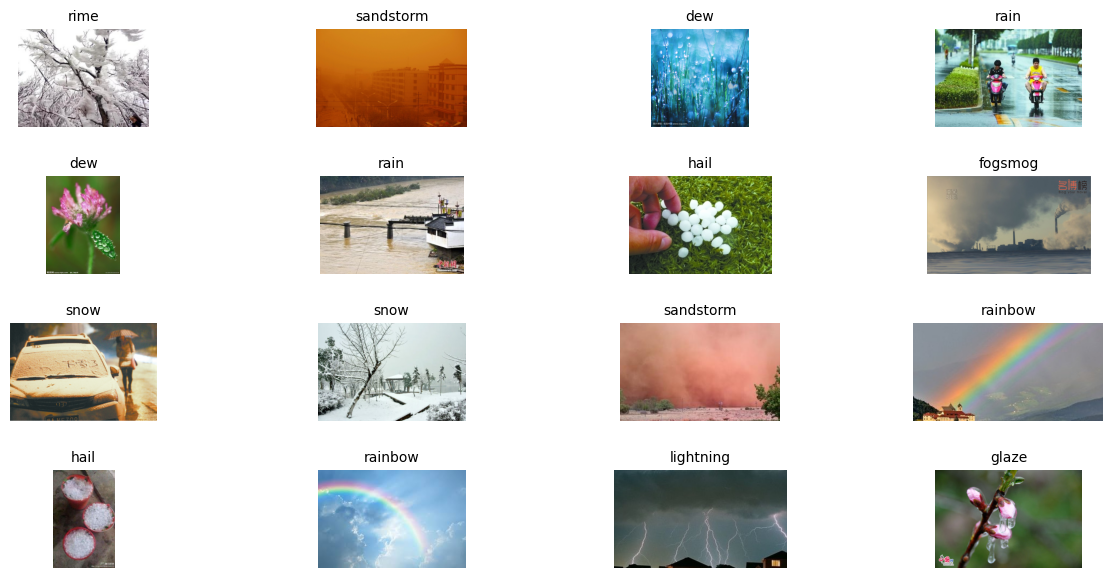

In [48]:
fig, axes = plt.subplots(4, 4, figsize=(15, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.3)  

for idx in range(16):  
    ax = axes[idx // 4, idx % 4]  
    ax.imshow(plt.imread(data.File_Path[idx]))
    ax.set_title(data.Labels[idx], fontsize=10)
    ax.axis('off')  

plt.show()


/scratch/1384505.1.p100/ipykernel_3348886/2586402217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts, palette="viridis")


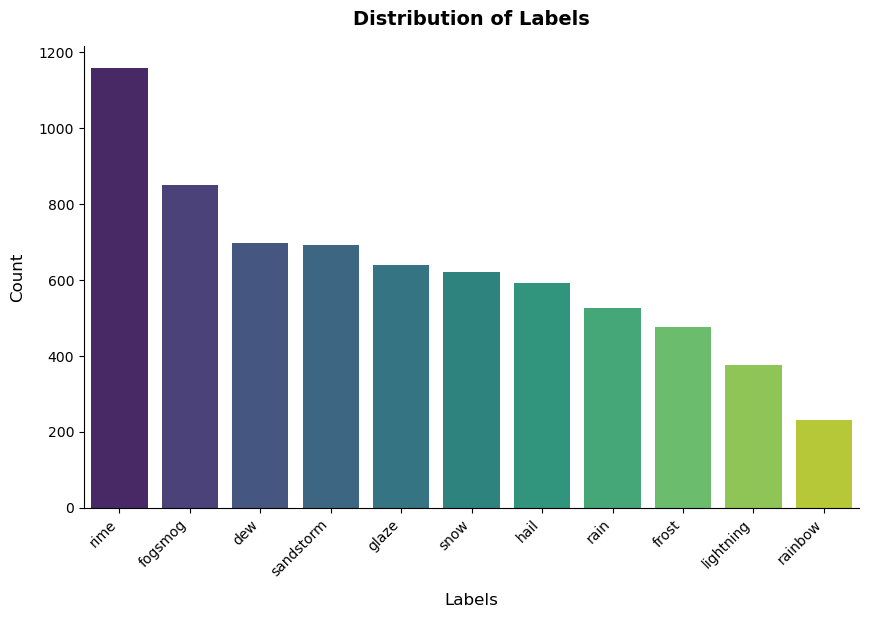

In [49]:
counts = data.Labels.value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts, palette="viridis")
plt.title('Distribution of Labels', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Labels', fontsize=12, labelpad=10)
plt.ylabel('Count', fontsize=12, labelpad=10)
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.yticks(fontsize=10)
sns.despine()

plt.show()

Train, Test split

In [50]:
train_df, test_df = train_test_split(data, test_size=0.2, random_state=2)

In [51]:
def gen(pre, train, test):
    common_params = {
        'target_size': (100, 100),
        'class_mode': 'categorical',
        'batch_size': 32,
        'fill_mode': 'nearest',
        'seed': 0
    }

    augmentation_params = {
        'rotation_range': 30,
        'zoom_range': 0.15,
        'width_shift_range': 0.2,
        'height_shift_range': 0.2,
        'shear_range': 0.15,
        'horizontal_flip': True
    }

    train_datagen = ImageDataGenerator(preprocessing_function=pre, validation_split=0.2, **augmentation_params)
    test_datagen = ImageDataGenerator(preprocessing_function=pre)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train,
        x_col='File_Path',
        y_col='Labels',
        subset='training',
        shuffle=True,
        **common_params
    )
    valid_gen = train_datagen.flow_from_dataframe(
        dataframe=train,
        x_col='File_Path',
        y_col='Labels',
        subset='validation',
        shuffle=False,
        **common_params
    )
    test_gen = test_datagen.flow_from_dataframe(
        dataframe=test,
        x_col='File_Path',
        y_col='Labels',
        color_mode='rgb',
        shuffle=False,
        verbose=0,
        **common_params
    )
    
    return train_gen, valid_gen, test_gen


In [52]:
def func(name_model):
    pre_model = name_model(
        input_shape=(100, 100, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    pre_model.trainable = False

    dense_params = {
        'units': 100,
        'activation': 'relu'
    }

    inputs = pre_model.input
    x = Dense(**dense_params)(pre_model.output)
    x = Dense(**dense_params)(x)
    outputs = Dense(11, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer='Adam',
        metrics=['accuracy']
    )

    early_stopping_params = {
        'monitor': 'val_loss',
        'min_delta': 0,
        'patience': 2,
        'mode': 'auto'
    }

    my_callbacks = [EarlyStopping(**early_stopping_params)]

    return model, my_callbacks


In [53]:
def plot(history, test_gen, train_gen, model):
    metrics = {'accuracy': 'Accuracy', 'loss': 'Loss'}
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for i, (metric, label) in enumerate(metrics.items()):
        axes[i].plot(history.history[metric], label=f'Train {label}')
        axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {label}')
        axes[i].set_title(f'Model {label}')
        axes[i].set_xlabel('Epochs')
        axes[i].set_ylabel(label)
        axes[i].legend(loc='best')
    plt.tight_layout()
    plt.show()

    pred = np.argmax(model.predict(test_gen), axis=1)
    class_labels = {v: k for k, v in train_gen.class_indices.items()}
    predicted_labels = [class_labels[idx] for idx in pred]

    cm = confusion_matrix(test_df.Labels, predicted_labels)
    clr = classification_report(test_df.Labels, predicted_labels)
    print(clr)

    fig, axes = plt.subplots(4, 3, figsize=(12, 8))
    for idx, ax in enumerate(axes.flat):
        image_path = test_df.File_Path.iloc[idx]
        true_label = test_df.Labels.iloc[idx]
        pred_label = predicted_labels[idx]
        ax.imshow(plt.imread(image_path))
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return history


In [54]:
def result_test(test,model_use):
    results = model_use.evaluate(test, verbose=0)
    
    print("    Test Loss: {:.5f}".format(results[0]))
    print("Test Accuracy: {:.2f}%".format(results[1] * 100))
    
    return results

Train Models

CNN model

Found 4392 validated image filenames belonging to 11 classes.
Found 1097 validated image filenames belonging to 11 classes.
Found 1373 validated image filenames belonging to 11 classes.


/share/pkg.8/academic-ml/fall-2024/install/fall-2024-tf/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/share/pkg.8/academic-ml/fall-2024/install/fall-2024-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1:
  Training Accuracy: 0.4237
  Validation Accuracy: 0.5579
Epoch 2:
  Training Accuracy: 0.5842
  Validation Accuracy: 0.6026
Epoch 3:
  Training Accuracy: 0.6182
  Validation Accuracy: 0.6317
Epoch 4:
  Training Accuracy: 0.6318
  Validation Accuracy: 0.6335
Epoch 5:
  Training Accuracy: 0.6439
  Validation Accuracy: 0.6007


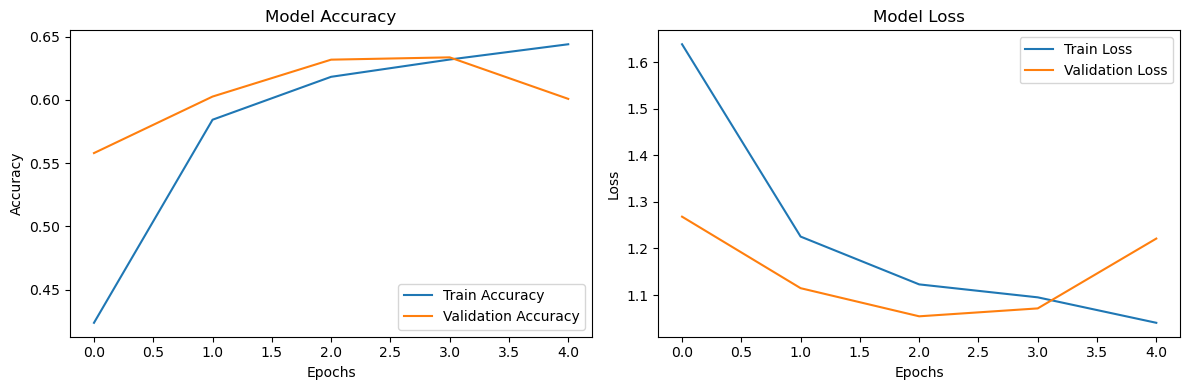

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step
              precision    recall  f1-score   support

         dew       0.91      0.72      0.80       133
     fogsmog       0.76      0.82      0.79       169
       frost       0.42      0.43      0.42        89
       glaze       0.50      0.52      0.51       120
        hail       0.76      0.45      0.56       125
   lightning       0.68      0.84      0.75        82
        rain       0.66      0.48      0.55       113
     rainbow       0.68      0.60      0.64        47
        rime       0.81      0.71      0.76       250
   sandstorm       0.72      0.89      0.79       117
        snow       0.40      0.64      0.49       128

    accuracy                           0.66      1373
   macro avg       0.66      0.64      0.64      1373
weighted avg       0.68      0.66      0.66      1373



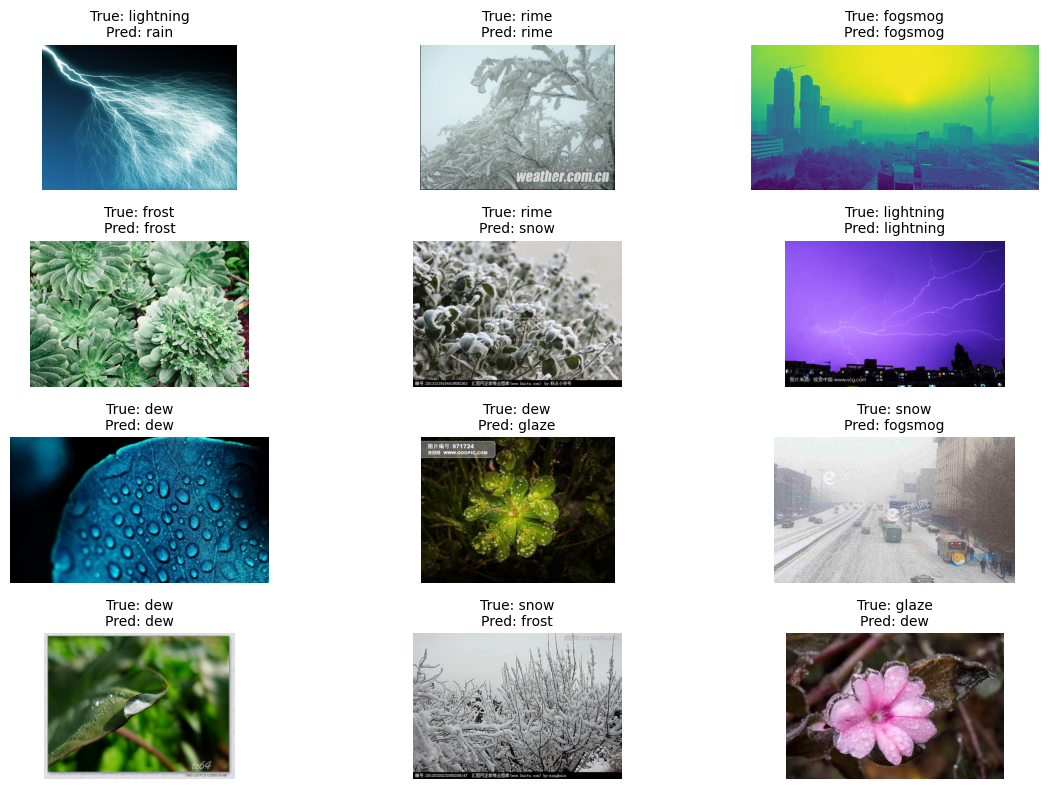

    Test Loss: 1.00704
Test Accuracy: 65.99%


In [55]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

def create_custom_cnn(input_shape=(100, 100, 3)):
    """
    Function to create a custom CNN model.
    """
    model = models.Sequential()
    
    # Convolutional layer 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Convolutional layer 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Convolutional layer 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Flatten the output to feed into the dense layers
    model.add(layers.Flatten())
    
    # Dense layer 1
    model.add(layers.Dense(128, activation='relu'))
    
    # Dense layer 2 
    model.add(layers.Dense(11, activation='softmax'))  # Assuming 11 classes for weather types
    
    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    
    return model

def custom_cnn_func():
    """
    Create and compile the custom CNN model.
    """
    # Instantiate the custom CNN model
    custom_cnn_model = create_custom_cnn(input_shape=(100, 100, 3))
    
    # Set up early stopping to prevent overfitting
    my_callbacks = [EarlyStopping(monitor='val_loss', min_delta=0, patience=2, mode='auto')]
    
    return custom_cnn_model, my_callbacks

# Generate the train, validation, and test generators using the previously defined `gen` function
train_gen_custom, valid_gen_custom, test_gen_custom = gen(preprocess_input, train_df, test_df)

# Create the custom CNN model and its callbacks
custom_cnn_model, custom_callbacks = custom_cnn_func()

# Train the custom CNN model
history_custom_cnn = custom_cnn_model.fit(
    train_gen_custom,
    validation_data=valid_gen_custom,
    epochs=100,
    callbacks=custom_callbacks,
    verbose=0
)

for epoch in range(len(history_custom_cnn.history['accuracy'])):
    print(f"Epoch {epoch + 1}:")
    print(f"  Training Accuracy: {history_custom_cnn.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy: {history_custom_cnn.history['val_accuracy'][epoch]:.4f}")

# Plot the training and validation history
custom_cnn_history = plot(history_custom_cnn, test_gen_custom, train_gen_custom, custom_cnn_model)

# Evaluate the model on the test data
result_custom_cnn = result_test(test_gen_custom, custom_cnn_model)


We first trained the single CNN model for baseline (Naive). However, we got an insight that the accuracy is not satisfying as we thought. 

Train accuracy : approx 64%
Test accuracy : approx 66%

Therefore, we will use advanced CNN models to improve the accuracy. 

VGG19 model

Found 4392 validated image filenames belonging to 11 classes.
Found 1097 validated image filenames belonging to 11 classes.
Found 1373 validated image filenames belonging to 11 classes.


/share/pkg.8/academic-ml/fall-2024/install/fall-2024-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1:
  Training Accuracy: 0.5663
  Validation Accuracy: 0.6782
Epoch 2:
  Training Accuracy: 0.7172
  Validation Accuracy: 0.7311
Epoch 3:
  Training Accuracy: 0.7527
  Validation Accuracy: 0.7311
Epoch 4:
  Training Accuracy: 0.7867
  Validation Accuracy: 0.7712
Epoch 5:
  Training Accuracy: 0.7935
  Validation Accuracy: 0.7685
Epoch 6:
  Training Accuracy: 0.8074
  Validation Accuracy: 0.7885
Epoch 7:
  Training Accuracy: 0.8308
  Validation Accuracy: 0.7812
Epoch 8:
  Training Accuracy: 0.8352
  Validation Accuracy: 0.7858
Epoch 9:
  Training Accuracy: 0.8367
  Validation Accuracy: 0.7830
Epoch 10:
  Training Accuracy: 0.8477
  Validation Accuracy: 0.7931
Epoch 11:
  Training Accuracy: 0.8429
  Validation Accuracy: 0.7794


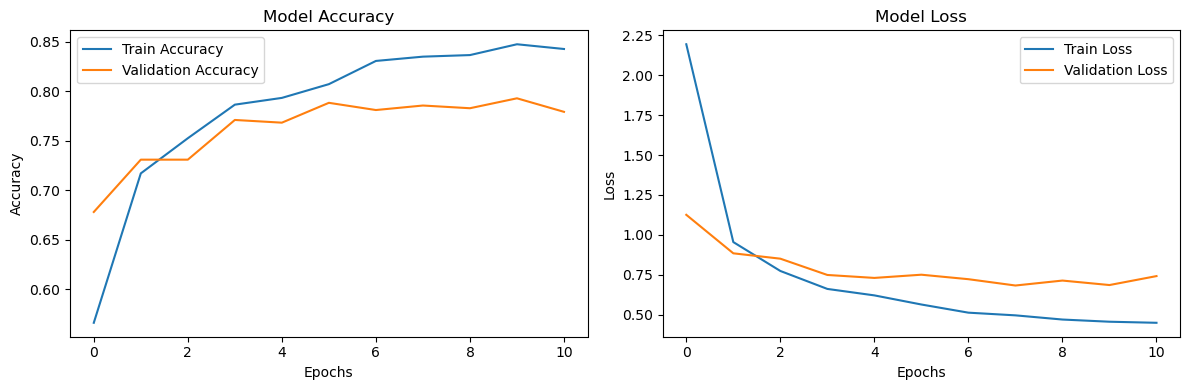

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step
              precision    recall  f1-score   support

         dew       0.86      0.78      0.82       133
     fogsmog       0.87      0.82      0.85       169
       frost       0.44      0.65      0.53        89
       glaze       0.65      0.56      0.60       120
        hail       0.85      0.79      0.82       125
   lightning       0.91      0.89      0.90        82
        rain       0.77      0.86      0.81       113
     rainbow       0.90      0.96      0.93        47
        rime       0.78      0.82      0.80       250
   sandstorm       0.84      0.88      0.86       117
        snow       0.72      0.56      0.63       128

    accuracy                           0.77      1373
   macro avg       0.78      0.78      0.78      1373
weighted avg       0.78      0.77      0.78      1373



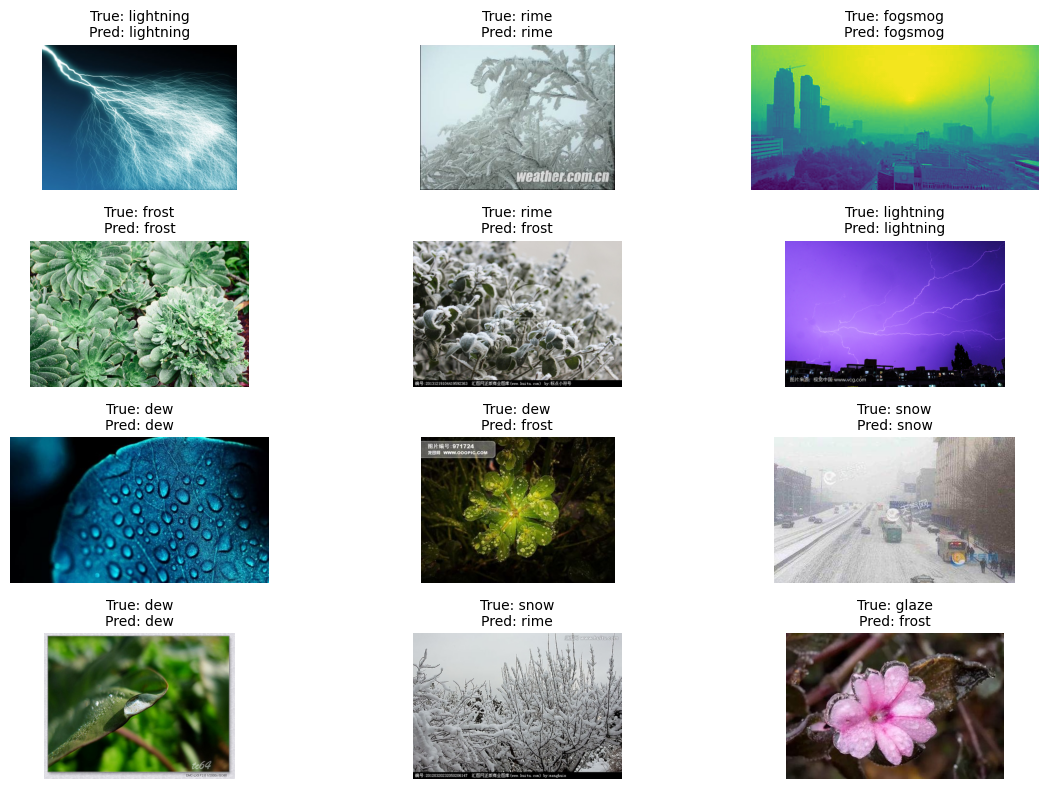

    Test Loss: 0.84628
Test Accuracy: 77.42%


In [57]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

# Create the VGG19-based model
def create_vgg19_model(input_shape=(100, 100, 3), num_classes=11):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    output_layer = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output_layer)
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

vgg19_model = create_vgg19_model(input_shape=(100, 100, 3), num_classes=11)

# Define the callback
callback = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

# Generate data generators
train_gen_vgg19, valid_gen_vgg19, test_gen_vgg19 = gen(preprocess_input, train_df, test_df)

# Train the VGG19 model
history_vgg19 = vgg19_model.fit(
    train_gen_vgg19,
    validation_data=valid_gen_vgg19,
    epochs=100,
    callbacks=callback,
    verbose=0
)

# Print the training accuracy and validation accuracy
for epoch in range(len(history_vgg19.history['accuracy'])):
    print(f"Epoch {epoch + 1}:")
    print(f"  Training Accuracy: {history_vgg19.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy: {history_vgg19.history['val_accuracy'][epoch]:.4f}")

# Plot the results
history_vgg19 = plot(history_vgg19, test_gen_vgg19, train_gen_vgg19, vgg19_model)

# Evaluate the model on the test set
result_vgg19 = result_test(test_gen_vgg19, vgg19_model)


Resnet Model

Found 4392 validated image filenames belonging to 11 classes.
Found 1097 validated image filenames belonging to 11 classes.
Found 1373 validated image filenames belonging to 11 classes.
Epoch 1/100


/share/pkg.8/academic-ml/fall-2024/install/fall-2024-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


138/138 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.6131 - loss: 1.2394 - val_accuracy: 0.7666 - val_loss: 0.7237
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.8139 - loss: 0.5650 - val_accuracy: 0.7922 - val_loss: 0.6320
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step - accuracy: 0.8266 - loss: 0.4779 - val_accuracy: 0.7885 - val_loss: 0.5946
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.8389 - loss: 0.4651 - val_accuracy: 0.8049 - val_loss: 0.5945
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 174ms/step - accuracy: 0.8571 - loss: 0.3958 - val_accuracy: 0.8304 - val_loss: 0.5167
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step - accuracy: 0.8622 - loss: 0.3826 - val_accuracy: 0.8204 - val_loss: 0.5858
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 174ms/step - accuracy: 0.8664 - loss: 0.3759 - val_accuracy: 0.8140 - val_loss: 0.5445
Epoch 1:
  Training Accuracy: 0.7072
  Validation Accuracy: 0.7666
Epoch 2:
  Training A

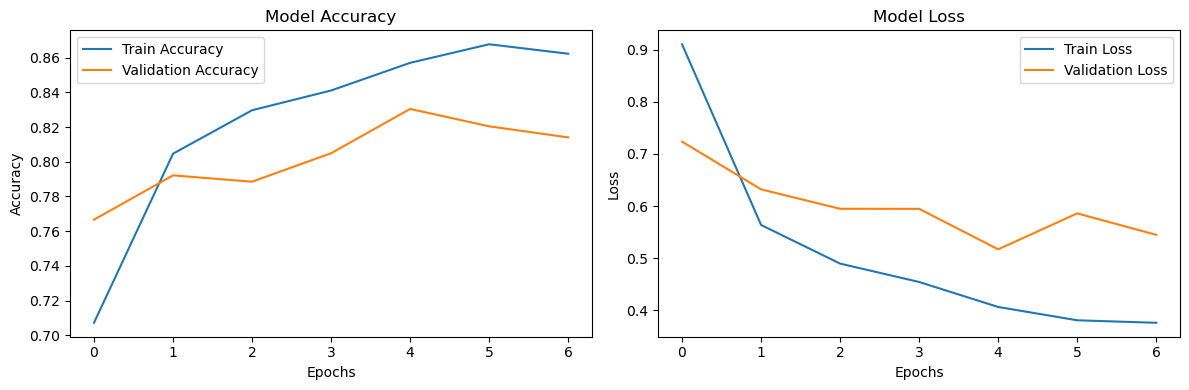

43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step
              precision    recall  f1-score   support

         dew       0.97      0.87      0.92       133
     fogsmog       0.88      0.90      0.89       169
       frost       0.59      0.76      0.67        89
       glaze       0.75      0.66      0.70       120
        hail       0.86      0.92      0.89       125
   lightning       0.96      0.98      0.97        82
        rain       0.94      0.78      0.85       113
     rainbow       0.98      0.89      0.93        47
        rime       0.78      0.90      0.84       250
   sandstorm       0.85      0.92      0.89       117
        snow       0.80      0.58      0.67       128

    accuracy                           0.84      1373
   macro avg       0.85      0.83      0.84      1373
weighted avg       0.84      0.84      0.83      1373



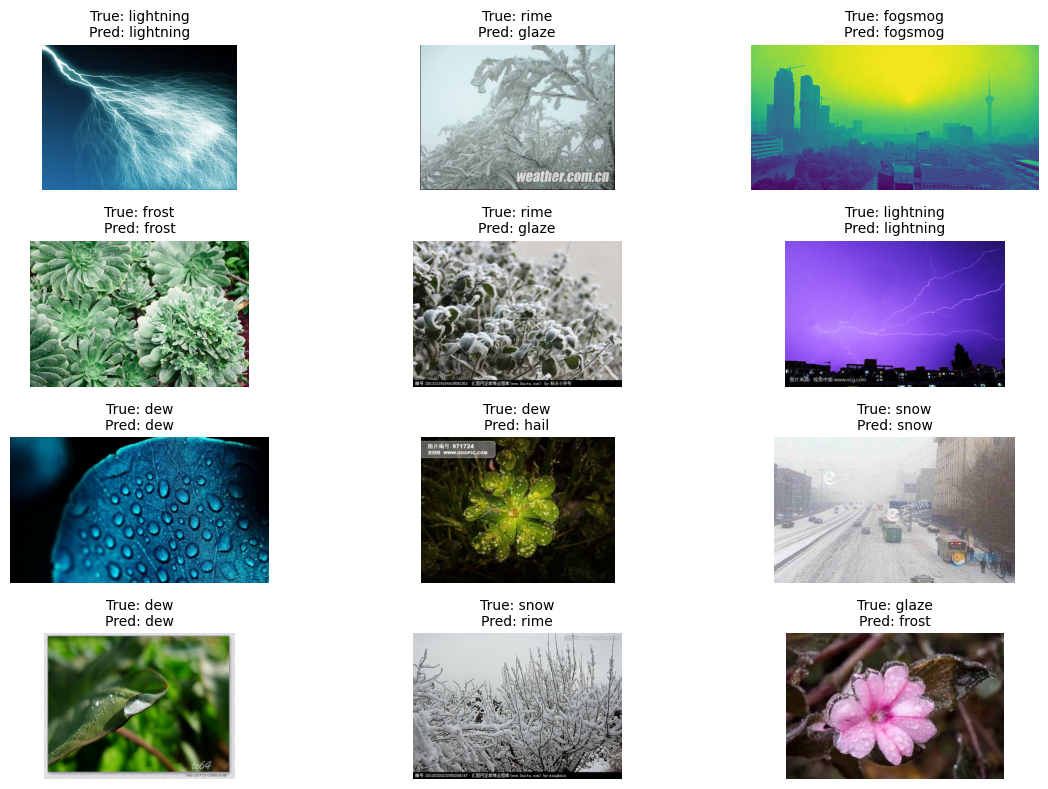

    Test Loss: 0.56652
Test Accuracy: 83.54%


In [58]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
callback = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]

def create_resnet_model(input_shape=(100, 100, 3), num_classes=11):
    """
    Function to create a ResNet50-based model for multi-class classification.
    """
    # Load the pre-trained ResNet50 model 
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model layers
    base_model.trainable = False
    
    # Add custom layers on top of ResNet50
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Global average pooling layer to reduce the output dimension
    x = Dense(128, activation='relu')(x)  # Fully connected layer
    output_layer = Dense(num_classes, activation='softmax')(x)  # Output layer for multi-class classification
    
    # Create the final model
    model = Model(inputs=base_model.input, outputs=output_layer)
    
    # Compile the model
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

# Create the ResNet model
resnet_model = create_resnet_model(input_shape=(100, 100, 3), num_classes=11)

# Generate data generators 
train_gen_resnet, valid_gen_resnet, test_gen_resnet = gen(preprocess_input, train_df, test_df)

# Train the ResNet model
history_resnet = resnet_model.fit(
    train_gen_resnet,
    validation_data=valid_gen_resnet,
    epochs=100,
    callbacks=callback,
    verbose=1 
)

# Print the training accuracy and validation accuracy for each epoch
for epoch in range(len(history_resnet.history['accuracy'])):
    print(f"Epoch {epoch + 1}:")
    print(f"  Training Accuracy: {history_resnet.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy: {history_resnet.history['val_accuracy'][epoch]:.4f}")

# Plot the results 
history_resnet = plot(history_resnet, test_gen_resnet, train_gen_resnet, resnet_model)

# Evaluate the model on the test set 
result_resnet = result_test(test_gen_resnet, resnet_model)


/scratch/1384505.1.p100/ipykernel_3348886/1210705941.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=input_shape)


Found 4392 validated image filenames belonging to 11 classes.
Found 1097 validated image filenames belonging to 11 classes.
Found 1373 validated image filenames belonging to 11 classes.


/share/pkg.8/academic-ml/fall-2024/install/fall-2024-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1:
  Training Accuracy: 0.6537
  Validation Accuracy: 0.7384
Epoch 2:
  Training Accuracy: 0.7682
  Validation Accuracy: 0.7584
Epoch 3:
  Training Accuracy: 0.8046
  Validation Accuracy: 0.7584
Epoch 4:
  Training Accuracy: 0.8256
  Validation Accuracy: 0.7739
Epoch 5:
  Training Accuracy: 0.8315
  Validation Accuracy: 0.7767
Epoch 6:
  Training Accuracy: 0.8397
  Validation Accuracy: 0.7912
Epoch 7:
  Training Accuracy: 0.8452
  Validation Accuracy: 0.7912
Epoch 8:
  Training Accuracy: 0.8490
  Validation Accuracy: 0.7803


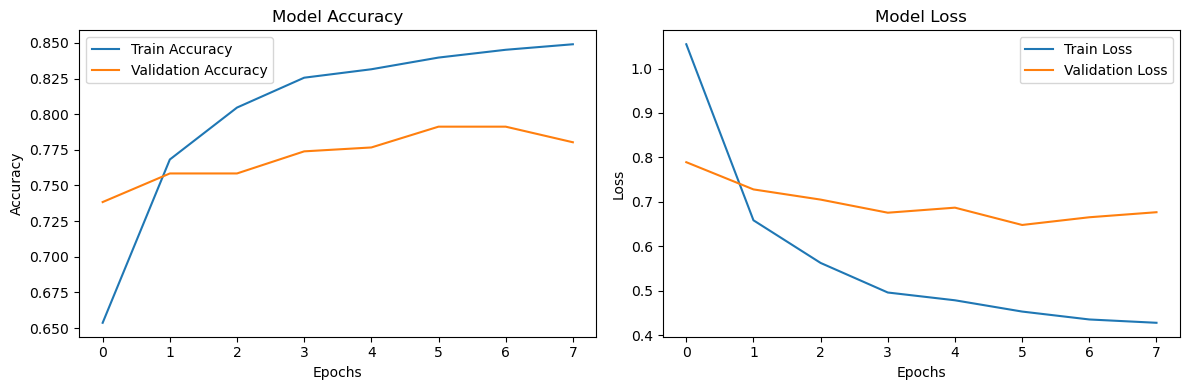

43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step
              precision    recall  f1-score   support

         dew       0.92      0.80      0.86       133
     fogsmog       0.85      0.83      0.84       169
       frost       0.59      0.62      0.60        89
       glaze       0.63      0.61      0.62       120
        hail       0.92      0.85      0.88       125
   lightning       0.94      0.96      0.95        82
        rain       0.87      0.85      0.86       113
     rainbow       0.96      0.94      0.95        47
        rime       0.78      0.90      0.83       250
   sandstorm       0.74      0.90      0.81       117
        snow       0.75      0.58      0.65       128

    accuracy                           0.80      1373
   macro avg       0.81      0.80      0.81      1373
weighted avg       0.81      0.80      0.80      1373



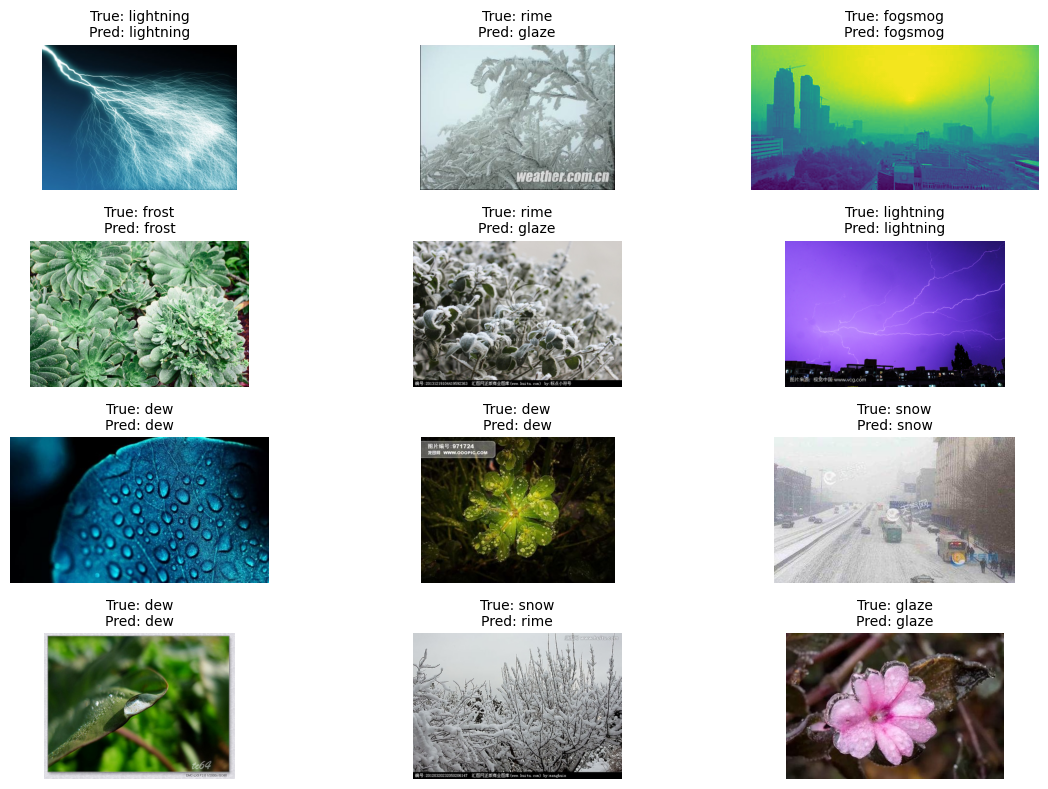

    Test Loss: 0.62318
Test Accuracy: 80.34%


In [59]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet import preprocess_input 
from tensorflow.keras.callbacks import EarlyStopping

def create_mobilenet_model(input_shape=(100, 100, 3), num_classes=11):
    """
    Function to create a MobileNet-based model for multi-class classification.
    """
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x) 
    x = Dense(128, activation='relu')(x)  
    output_layer = Dense(num_classes, activation='softmax')(x) 
    model = Model(inputs=base_model.input, outputs=output_layer)
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

mobilenet_model = create_mobilenet_model(input_shape=(100, 100, 3), num_classes=11)

# Generate data generators 
train_gen_mobilenet, valid_gen_mobilenet, test_gen_mobilenet = gen(preprocess_input, train_df, test_df)

# Set up early stopping to prevent overfitting
callback = [EarlyStopping(monitor='val_loss', min_delta=0, patience=2, mode='auto')]

# Train the MobileNet model
history_mobilenet = mobilenet_model.fit(
    train_gen_mobilenet,
    validation_data=valid_gen_mobilenet,
    epochs=100,
    callbacks=callback,
    verbose=0
)

# Print training accuracy after each epoch
for epoch in range(len(history_mobilenet.history['accuracy'])):
    print(f"Epoch {epoch + 1}:")
    print(f"  Training Accuracy: {history_mobilenet.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy: {history_mobilenet.history['val_accuracy'][epoch]:.4f}")

# Plot the training and validation history
mobilenet_history = plot(history_mobilenet, test_gen_mobilenet, train_gen_mobilenet, mobilenet_model)

# Evaluate the model on the test data
result_mobilenet = result_test(test_gen_mobilenet, mobilenet_model)


Interpretation

Pretrained Convolutional Neural Networks (CNNs), specifically transfer learning models. 

VGG19 -> Train: 84, Test : 77

VGG19 shows less overfitting but also has the lowest test accuracy.
This suggests that the model may be underfitting, indicating it might not be complex enough to capture the dataset's nuances.

Resnet -> Train : 86, Test : 84

ResNet50 achieves the highest test accuracy with minimal overfitting.
The architecture's ability to handle vanishing gradients (via skip connections) helps it generalize better.
This makes ResNet50 the most reliable choice for our dataset.

MobileNet -> Train : 85, Test : 80

MobileNet has a high risk of overfitting as the gap between train and test accuracy is larger than the gap of ResNet50.
MobileNet is computationally efficient and might be a better choice for mobile or resource-constrained environments, but accuracy trade-offs are evident.

Hyperparameter for ResNet50 -> 
Input shape: (100, 100, 3), Output classes: 11, Dense layer units: 128, Activation: ReLU and softmax, Optimizer: Adam, Loss: categorical_crossentropy, Metric: accuracy, Epochs: 100, Batch size: 32, EarlyStopping: val_loss (patience: 2, restore_best_weights: True), Data augmentation: rotation, zoom, shift, shear, horizontal flip.

Now we are going to use ResNet50 to classify external dataset. 

In [85]:
import zipfile
import os
import pandas as pd

zip_file_path = '/projectnb/ds340/students/seokhoon/dataset-2..zip'
output_folder = '/projectnb/ds340/students/seokhoon/dataset-2._extracted'

def extract_zip(zip_file_path, output_folder):
    """
    Extracts the ZIP file to the specified output folder.
    """
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(output_folder)
    print(f'Files extracted to {output_folder} successfully.')

extract_zip(zip_file_path, output_folder)

def collect_image_paths(folder_path):
    """
    Collect all JPG image paths from the extracted folder.
    """
    file_paths = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith('.jpg'):  # Only include JPG files
                file_paths.append(os.path.join(root, file))
    return file_paths

image_paths = collect_image_paths(output_folder)

data = pd.DataFrame(image_paths, columns=['File_Path'])
data['Labels'] = '' 
print(f"Loaded {len(data)} image paths.")
print(data.head())


Files extracted to /projectnb/ds340/students/seokhoon/dataset-2._extracted successfully.
Loaded 2204 image paths.
                                           File_Path Labels
0  /projectnb/ds340/students/seokhoon/dataset-2._...       
1  /projectnb/ds340/students/seokhoon/dataset-2._...       
2  /projectnb/ds340/students/seokhoon/dataset-2._...       
3  /projectnb/ds340/students/seokhoon/dataset-2._...       
4  /projectnb/ds340/students/seokhoon/dataset-2._...       


Valid images found: 1102
Found 1102 validated image filenames.
 1/35 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step

/share/pkg.8/academic-ml/fall-2024/install/fall-2024-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
Predictions saved to predictions_from_dataset2.csv


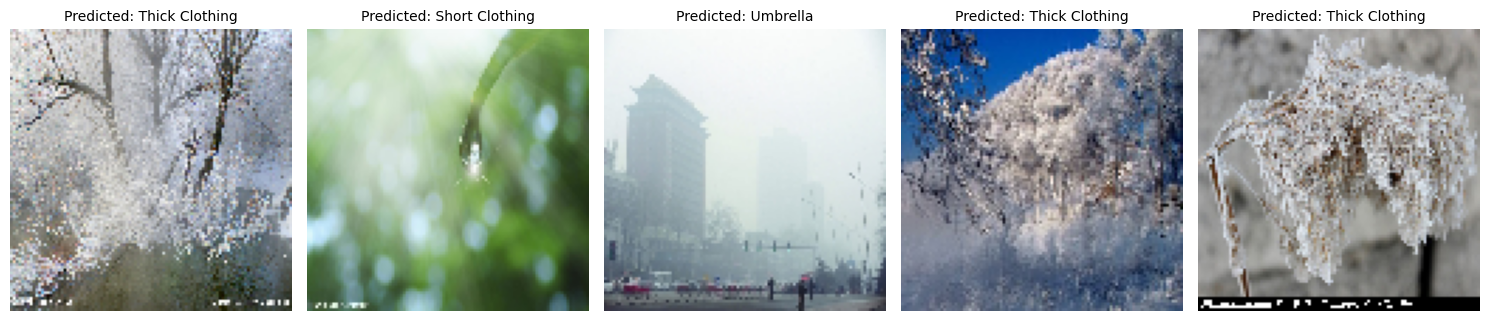

Overall Accuracy: 0.00%
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step
Test Data Accuracy: 83.54%


In [93]:
# Step 1: DataFrame 
import os
import pandas as pd
from PIL import Image

# check valid image
def validate_image(file_path):
    """
    Check if the file is a valid image.
    """
    try:
        with Image.open(file_path) as img:
            img.verify()  # Check if the file is an image
        return True
    except Exception:
        return False

# JPG path
def create_valid_dataframe(data_dir):
    """
    Create a DataFrame of valid image files.
    """
    file_paths = []
    for root, _, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith('.jpg'):
                file_paths.append(os.path.join(root, file))
    
    # Create DataFrame
    data = pd.DataFrame(file_paths, columns=['File_Path'])
    data['Labels'] = ''  
    
    # Filter valid images
    valid_file_paths = [path for path in data['File_Path'] if validate_image(path)]
    data = pd.DataFrame(valid_file_paths, columns=['File_Path'])
    data['Labels'] = ''  
    print(f"Valid images found: {len(data)}")
    return data

dataset_dir = '/projectnb/ds340/students/seokhoon/dataset-2._extracted'
data = create_valid_dataframe(dataset_dir)

# Step 2: ImageDataGenerator 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ImageDataGenerator 
data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# use flow_from_dataframe 
data_generator = data_gen.flow_from_dataframe(
    dataframe=data,
    x_col='File_Path',
    y_col=None,  
    target_size=(100, 100),  
    batch_size=32,
    class_mode=None, 
    shuffle=False
)

# Step 3: predict model
import numpy as np

predictions = resnet_model.predict(data_generator)
predicted_classes = np.argmax(predictions, axis=1)

# class mapping
class_mapping = {0: 'Short Clothing', 1: 'Umbrella', 2: 'Thick Clothing', 3: 'Thick Clothing', 4: 'Thick Clothing',
                 5: 'Thick Clothing', 6: 'Thick Clothing', 7: 'Short Clothing', 8: 'Thick Clothing', 9: 'Thick Clothing', 10: 'Short Clothing'}
predicted_labels = [class_mapping[idx] for idx in predicted_classes]

data['Predicted_Label'] = predicted_labels

# Step 4: save result
output_csv_path = 'predictions_from_dataset2.csv'
data.to_csv(output_csv_path, index=False)
print(f"Predictions saved to {output_csv_path}")

# Step 5: visualize result
import random
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt

def visualize_predictions_random(data, num_images=5):
    """
    Visualize random predictions with their corresponding images.
    """
    sampled_data = data.sample(n=min(num_images, len(data)), random_state=random.randint(0, 1000))

    plt.figure(figsize=(15, 5))
    for i, (_, row) in enumerate(sampled_data.iterrows()):
        img_path = row['File_Path']
        img = load_img(img_path, target_size=(100, 100)) 
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Predicted: {row['Predicted_Label']}", fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions_random(data, num_images=5)


# Overall Accuracy (for validation dataset or predicted dataset with true labels)
from sklearn.metrics import accuracy_score
if 'Labels' in data.columns and data['Labels'].nunique() > 0:
    overall_accuracy = accuracy_score(data['Labels'], data['Predicted_Label'])
    print(f"Overall Accuracy: {overall_accuracy:.2%}")
else:
    print("Actual labels are not available. Cannot compute accuracy.")

# Test Accuracy
test_predictions = resnet_model.predict(test_gen_resnet)
test_predicted_classes = np.argmax(test_predictions, axis=1)
test_actual_classes = test_gen_resnet.classes
test_accuracy = accuracy_score(test_actual_classes, test_predicted_classes)
print(f"Test Data Accuracy: {test_accuracy:.2%}")


Finally, we made a weather classification model that predicts the model and the suitable clothing. 